# Analysis of predictions & Optimization of staff


These analyses were conducted on April 1, 2026, allowing us to compare the forecasts provided to Aristide with the actual data.

All these analyses are performed in a single day, but they can be scaled up.

Furthermore, the staff optimization component is currently limited to a single day, but as the model is improved, it will be possible to generate optimized staff schedules for future days, such as one month in advance. 

---
## Setup

### Imports

In [67]:
import os
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error

# Required to avoid import bugs
root_path = Path.cwd().parent.parent
sys.path.append(str(root_path))

### Global variables

In [ ]:
root = Path(os.getcwd()).parent.parent
DATA_FOLDER_PATH = os.path.join(root, "data_analysis")
OUTPUT_FOLDER_PATH = os.path.join(root, "output")

PREDICTIONS  = os.path.join(DATA_FOLDER_PATH, "predictions_04-01_04-02.csv")
RESULTS  = os.path.join(DATA_FOLDER_PATH, "result_predictions_04-01.csv")
FILENAME_REPORT = os.path.join(OUTPUT_FOLDER_PATH, "planning_04-01.txt")

HOURLY_RATE = 25

### Preparation

In [69]:
df_pred = pd.read_csv(PREDICTIONS)
df_results = pd.read_csv(RESULTS)

df_pred["LTScheduledDatetime"] = pd.to_datetime(df_pred['LTScheduledDatetime'])
df_pred = df_pred[df_pred["LTScheduledDatetime"].dt.date == pd.to_datetime("2026-04-01").date()]

df_results["LTScheduledDatetime"] = pd.to_datetime(df_results['LTScheduledDatetime'])
df_results = df_results[df_results["LTScheduledDatetime"].dt.date == pd.to_datetime("2026-04-01").date()]

df_analysis = pd.merge(
    df_pred, 
    df_results, 
    on=['FlightNumberNormalized', 'LTScheduledDatetime'], 
    how='inner'
)

df_analysis['Heure'] = df_analysis['LTScheduledDatetime'].dt.hour
df_terminal = df_analysis[df_analysis["SysTerminal"] != "Terminal Non Affecté"]
df_hourly = df_analysis.groupby('Heure')[['NbPaxTotal', 'PredNbPaxTotal']].sum().reset_index()

---
## Analysis

### 1. MAE and Ratio

In [70]:
mae_pax = mean_absolute_error(df_analysis['NbPaxTotal'], df_analysis['PredNbPaxTotal'])
mae_phmr = mean_absolute_error(df_analysis['FarmsNbPaxPHMR'], df_analysis['PredFarmsNbPaxPHMR'])

print(f"MAE for Pax  : {mae_pax}")
print(f"MAE for PHMR : {mae_phmr} \n")

# -------------------------------------------

totals = df_analysis[['NbPaxTotal', 'PredNbPaxTotal']].sum()
diff = totals['PredNbPaxTotal'] - totals['NbPaxTotal']
ratio = (totals['PredNbPaxTotal'] / totals['NbPaxTotal']) * 100

print("---------------- Pasengers ----------------")
print(f"Global Real  : {totals['NbPaxTotal']:,.0f}")
print(f"Global Predict : {totals['PredNbPaxTotal']:,.0f}")
print(f"Difference : {diff:,.0f}")
print(f"Global Ratio : {ratio:.2f}% of real \n")

totals = df_analysis[['FarmsNbPaxPHMR', 'PredFarmsNbPaxPHMR']].sum()
diff = totals['PredFarmsNbPaxPHMR'] - totals['FarmsNbPaxPHMR']
ratio = (totals['PredFarmsNbPaxPHMR'] / totals['FarmsNbPaxPHMR']) * 100

print("------------------ PHMR ------------------")
print(f"Global Real  : {totals['FarmsNbPaxPHMR']:,.0f}")
print(f"Global Predict : {totals['PredFarmsNbPaxPHMR']:,.0f}")
print(f"Difference : {diff:,.0f}")
print(f"Global Ratio : {ratio:.2f}% of real")

MAE for Pax  : 28.070866141732285
MAE for PHMR : 0.9015748031496063 

---------------- Pasengers ----------------
Global Real  : 24,688
Global Predict : 24,022
Difference : -666
Global Ratio : 97.30% of real 

------------------ PHMR ------------------
Global Real  : 141
Global Predict : 98
Difference : -43
Global Ratio : 69.50% of real


- The ratio is close to 100% but the MAE is high, it means that the model accurately captures the airport's overall passenger volume, but it misallocates passengers across different flights (it gets the specific flights wrong, but the total count is correct).

---
### 2. Predictions by Hours

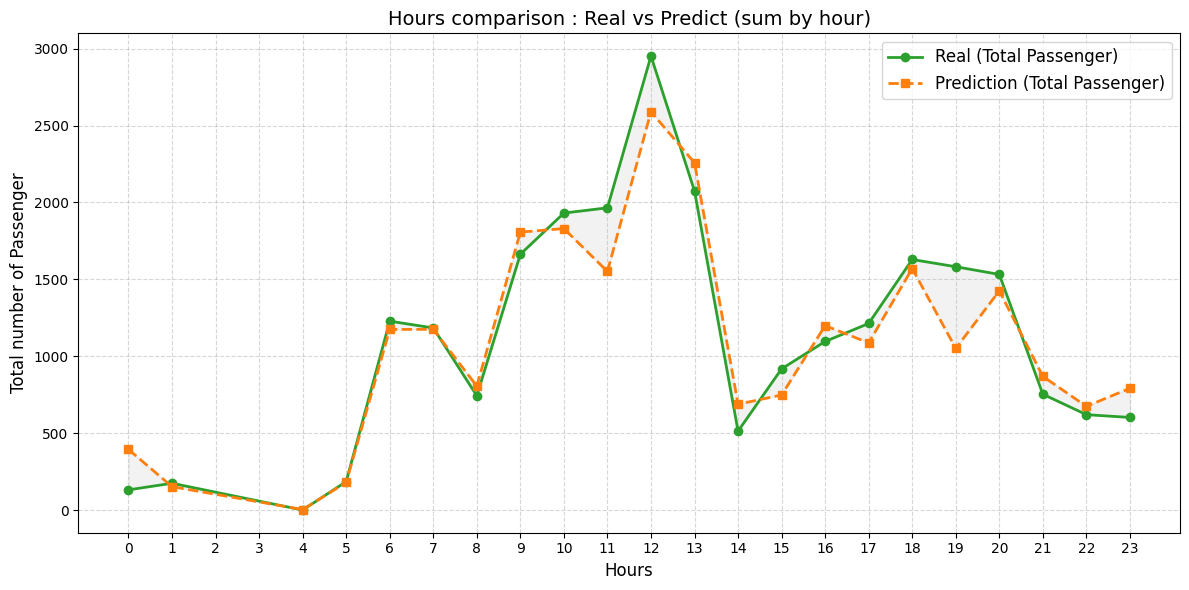

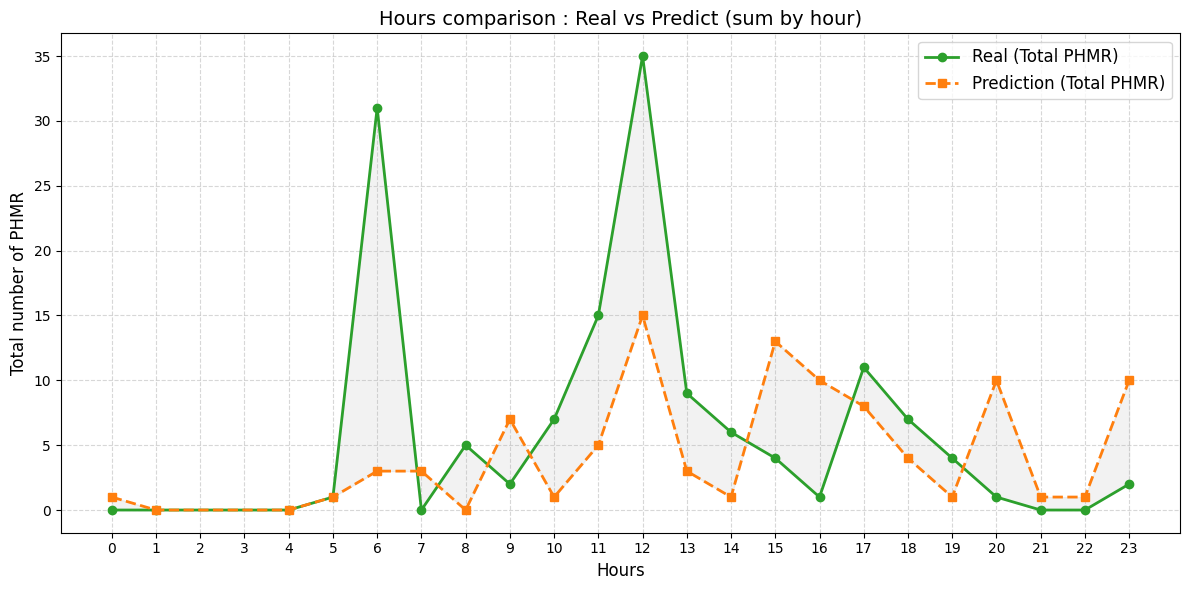

In [71]:
def plot_hours_comparison(df, pred_col, res_col, type_pax):

    hourly_stats = df.groupby('Heure')[[res_col, pred_col]].sum()
    plt.figure(figsize=(12, 6))

    plt.plot(hourly_stats.index, hourly_stats[res_col], 
            label=f'Real (Total {type_pax})', color='#2ca02c', marker='o', linewidth=2)
    plt.plot(hourly_stats.index, hourly_stats[pred_col], 
            label=f'Prediction (Total {type_pax})', color='#ff7f0e', linestyle='--', marker='s', linewidth=2)

    plt.title('Hours comparison : Real vs Predict (sum by hour)', fontsize=14)
    plt.xlabel('Hours', fontsize=12)
    plt.ylabel(f'Total number of {type_pax}', fontsize=12)
    plt.xticks(range(0, 24))
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.legend(fontsize=12)

    plt.fill_between(hourly_stats.index, hourly_stats[res_col], 
                    hourly_stats[pred_col], color='gray', alpha=0.1)

    plt.tight_layout()
    plt.show()

plot_hours_comparison(df_analysis,"PredNbPaxTotal", "NbPaxTotal", "Passenger")
plot_hours_comparison(df_analysis,"PredFarmsNbPaxPHMR", "FarmsNbPaxPHMR", "PHMR")

- The traffic analysis shows that the current model accurately tracks the airport’s daily dynamics, although it tends to underestimate traffic during peak hours (particularly between 11 a.m. and 1 p.m. and 6 p.m. and 8 p.m.).

-  For the specific segment of passengers with reduced mobility (PHRM), the model reaches a "ceiling", struggling to predict needs exceeding 15 passengers per flight. In addition, the model tends to predict a higher number of passengers.

--- 
### 3. Predictions by Terminal

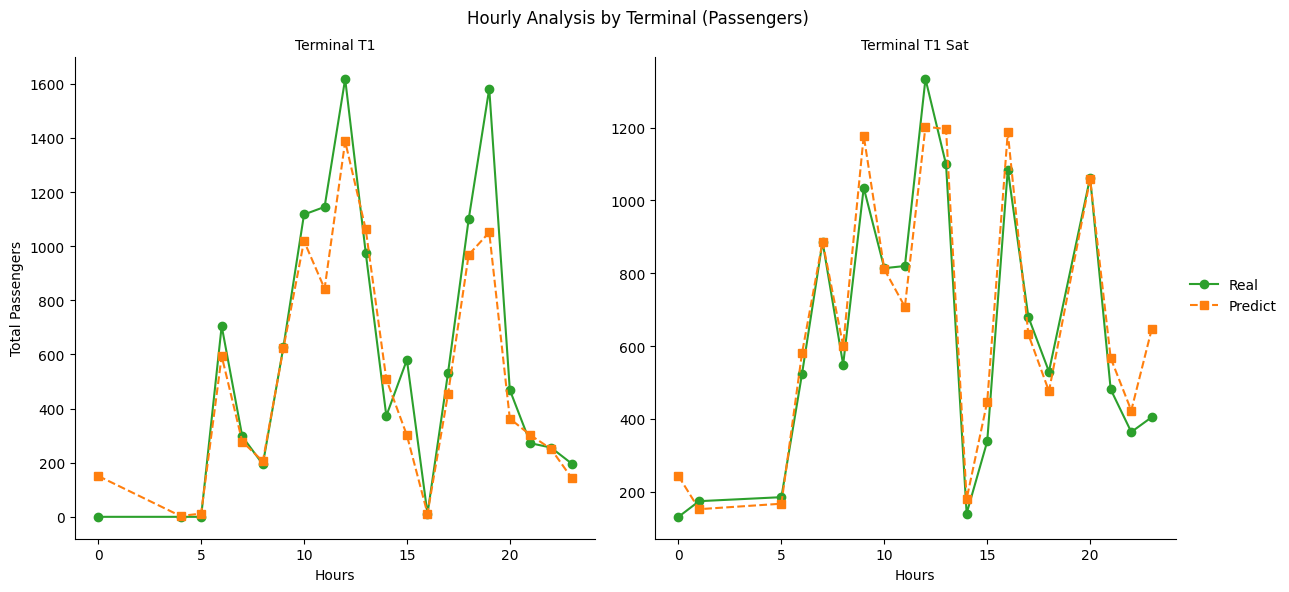

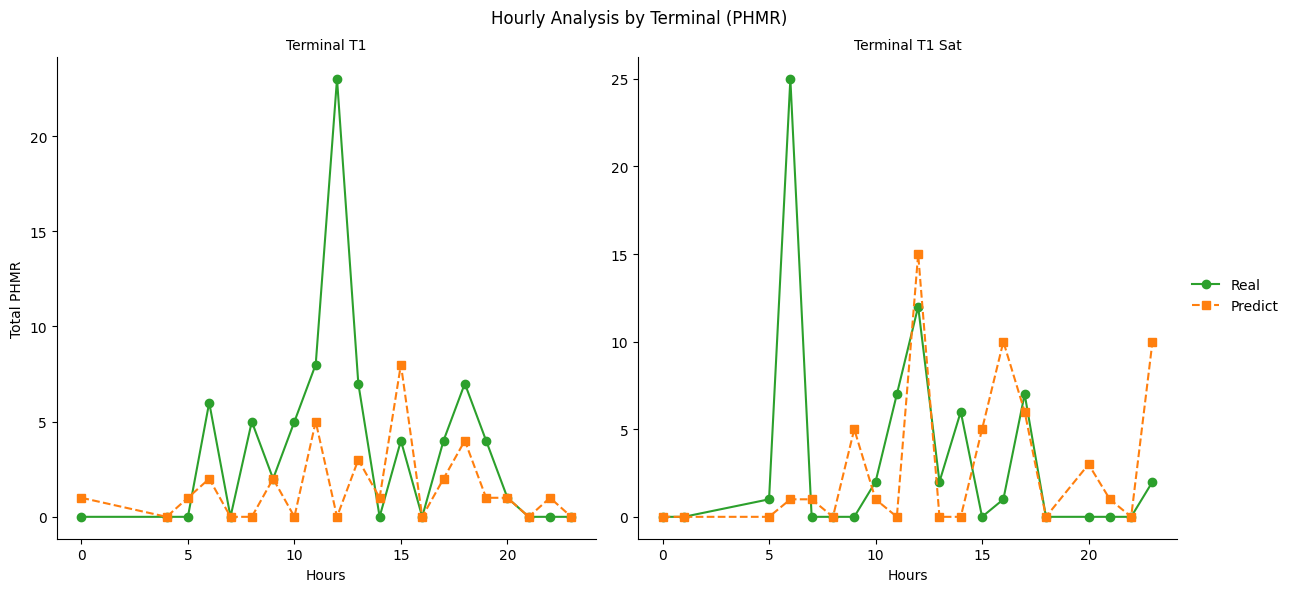

In [72]:
def plot_terminal_facets(df, pred_col, res_col, type_pax):
    
    df_melt = df.groupby(['Heure', 'SysTerminal'])[[res_col, pred_col]].sum().reset_index()
    
    g = sns.FacetGrid(df_melt, col="SysTerminal", col_wrap=2, height=6, sharey=False)
    
    g.map(plt.plot, "Heure", res_col, color="#2ca02c", marker="o", label="Real")
    g.map(plt.plot, "Heure", pred_col, color="#ff7f0e", linestyle="--", marker="s", label="Predict")
    
    g.add_legend()
    g.set_axis_labels("Hours", f"Total {type_pax}")
    g.set_titles("Terminal {col_name}")
    plt.subplots_adjust(top=0.9)
    g.fig.suptitle(f'Hourly Analysis by Terminal ({type_pax})')
    plt.show()


plot_terminal_facets(df_terminal, "PredNbPaxTotal", "NbPaxTotal", "Passengers")
plot_terminal_facets(df_terminal, "PredFarmsNbPaxPHMR", "FarmsNbPaxPHMR", "PHMR")

- A analysis of the terminals reveals that the model behaves differently depending on the traffic pattern. At Terminal T1, there is greater volatility with very isolated peaks (particularly at 12:00 p.m. and 7:00 p.m.) that the model consistently underestimates. Conversely, at Terminal T1 Sat, the prediction curve aligns much better with reality, showing that the model performs very well with more regular or better-distributed flows.

- The model consistently underestimates PHMR volumes when broken down by terminal, it reflects the analysis made before. This is a criticalspot : in an airport, PHMR assistance staff cannot easily move between terminals due to security checkpoints and distance. If the model predicts 10 PHMR for Terminal T1 but 25 actually arrive, the service quality collapses locally, even if the total airport count was "correct". This suggests that the model is "averaging out" the needs instead of recognizing that certain flight rotations or specific gates in a given terminal attract a much higher density of assistance requests.


---
### 4. Predictions by Arrival and Departure

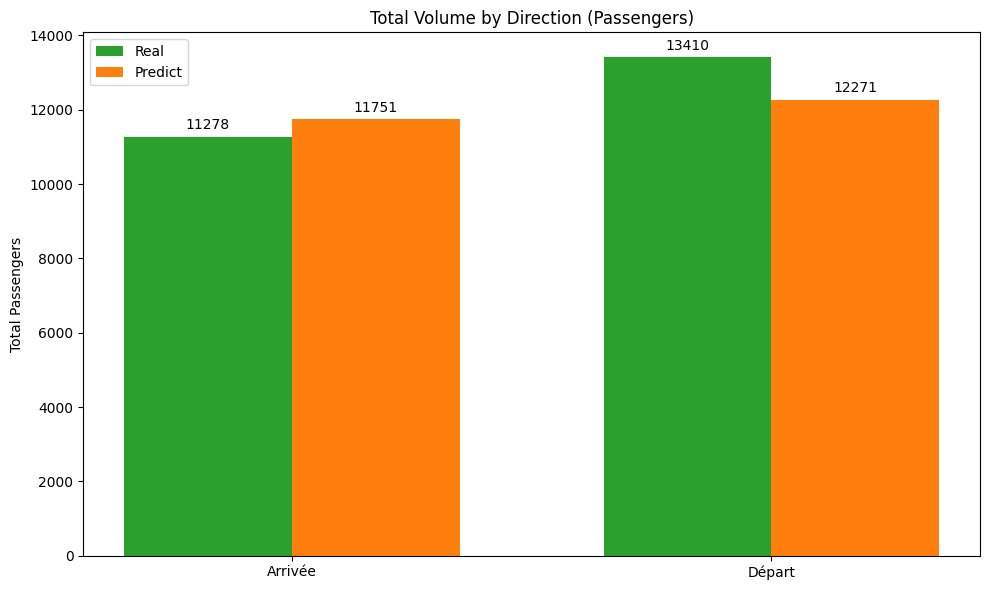

In [73]:
def plot_direction_comparison(df, pred_col, res_col, type_pax):
    
    dir_stats = df.groupby('Direction')[[res_col, pred_col]].sum()
    
    labels = dir_stats.index
    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    rects1 = ax.bar(x - width/2, dir_stats[res_col], width, label='Real', color='#2ca02c')
    rects2 = ax.bar(x + width/2, dir_stats[pred_col], width, label='Predict', color='#ff7f0e')

    ax.set_ylabel(f'Total {type_pax}')
    ax.set_title(f'Total Volume by Direction ({type_pax})')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.legend()
    
    ax.bar_label(rects1, padding=3, fmt='%.0f')
    ax.bar_label(rects2, padding=3, fmt='%.0f')

    plt.tight_layout()
    plt.show()

plot_direction_comparison(df_analysis, "PredNbPaxTotal", "NbPaxTotal", "Passengers")

- The model tends to overestimate the number of departing passengers and underestimate the number of arriving passengers.

---
### 5. Arrivals and Departures by Terminal

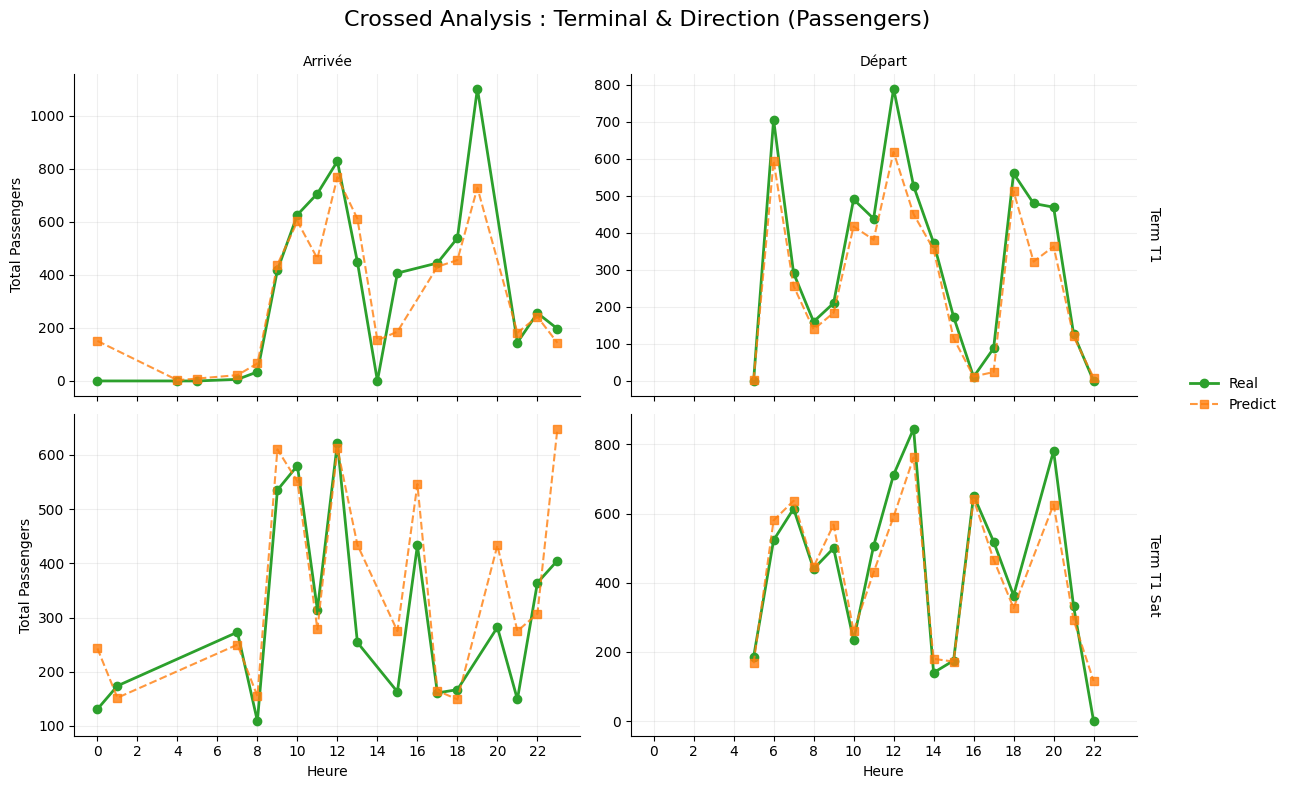

In [74]:
def plot_terminal_direction_grid(df, pred_col, res_col, type_pax):

    df_grid = df.groupby(['Heure', 'SysTerminal', 'Direction'])[[res_col, pred_col]].sum().reset_index()
    g = sns.FacetGrid(df_grid, row="SysTerminal", col="Direction", 
                      height=4, aspect=1.5, sharey=False, margin_titles=True)
  
    g.map(plt.plot, "Heure", res_col, color="#2ca02c", marker="o", label="Real", linewidth=2)
    g.map(plt.plot, "Heure", pred_col, color="#ff7f0e", linestyle="--", marker="s", label="Predict", alpha=0.8)
    
    g.add_legend()
    g.set_axis_labels("Heure", f"Total {type_pax}")
    g.set_titles(row_template="Term {row_name}", col_template="{col_name}")
    
    for ax in g.axes.flat:
        ax.set_xticks(range(0, 24, 2)) 
        ax.grid(True, alpha=0.2)
        
    plt.subplots_adjust(top=0.9)
    g.fig.suptitle(f'Crossed Analysis : Terminal & Direction ({type_pax})', fontsize=16)
    plt.show()

plot_terminal_direction_grid(df_terminal,  "PredNbPaxTotal", "NbPaxTotal", "Passengers")

- These plots show the volume of arrivals and departures by terminal. It is clear that the model performs less well for departures.

###  Employee Management Optimization

#### **Lane management** : 

 - **Capacity per lane :** 200 passenger per hour. 
 - **Staffing requirement :** 8 employees per lane. 
 - **HR constraint :** Any employee hired at time $T$ must remain on the payroll until $T+6$.


 The function below generates the optimal schedule for staff management based on passenger flow

In [75]:
def generate_optimal_planning(df_hourly, pax_col):
    """
    Computes an optimized staffing schedule based on hourly passenger forecasts.
    
    The function transforms passenger volume into required security lanes and 
    calculates the necessary workforce while adhering to a mandatory 6-hour 
    shift constraint. It ensures that enough staff is hired at any given hour 
    to meet the demand, accounting for employees already on duty from previous 
    hours.
    """
    # Immediate need for lanes (1 lane per 200 passengers)
    df_hourly['Lanes_Required'] = np.ceil(df_hourly[pax_col] / 200).astype(int)

    # Initializing “Active” and “New” Employees
    # Create a column for the number of people who START their shift at time H
    df_hourly['Staff_Starting'] = 0 
    
    # For each hour, we check whether the staff already on duty is sufficient.
    # If not, we hire the necessary staff, who will remain on duty for the next 5 hours.
    active_staff_per_hour = np.zeros(24)
    for h in range(24):
        needed_now = df_hourly.loc[h, 'Lanes_Required'] * 8  # 8 employees needed for one lane
        current_active = active_staff_per_hour[h]
        
        if current_active < needed_now:
            new_hires = needed_now - current_active
            df_hourly.loc[h, 'Staff_Starting'] = new_hires
            # These new employees will be active for the next 6 hours (from h to h+5)
            for i in range(h, min(h + 6, 24)):
                active_staff_per_hour[i] += new_hires
                
    df_hourly['Total_Staff_Present'] = active_staff_per_hour
    df_hourly['Lanes_Open'] = (df_hourly['Total_Staff_Present'] / 8).astype(int)
    
    return df_hourly

airport_hourly = pd.merge(pd.DataFrame({'Heure': range(24)}), df_hourly, on='Heure', how='left').fillna(0)
planning = generate_optimal_planning(airport_hourly, 'PredNbPaxTotal')

### Plot planning :

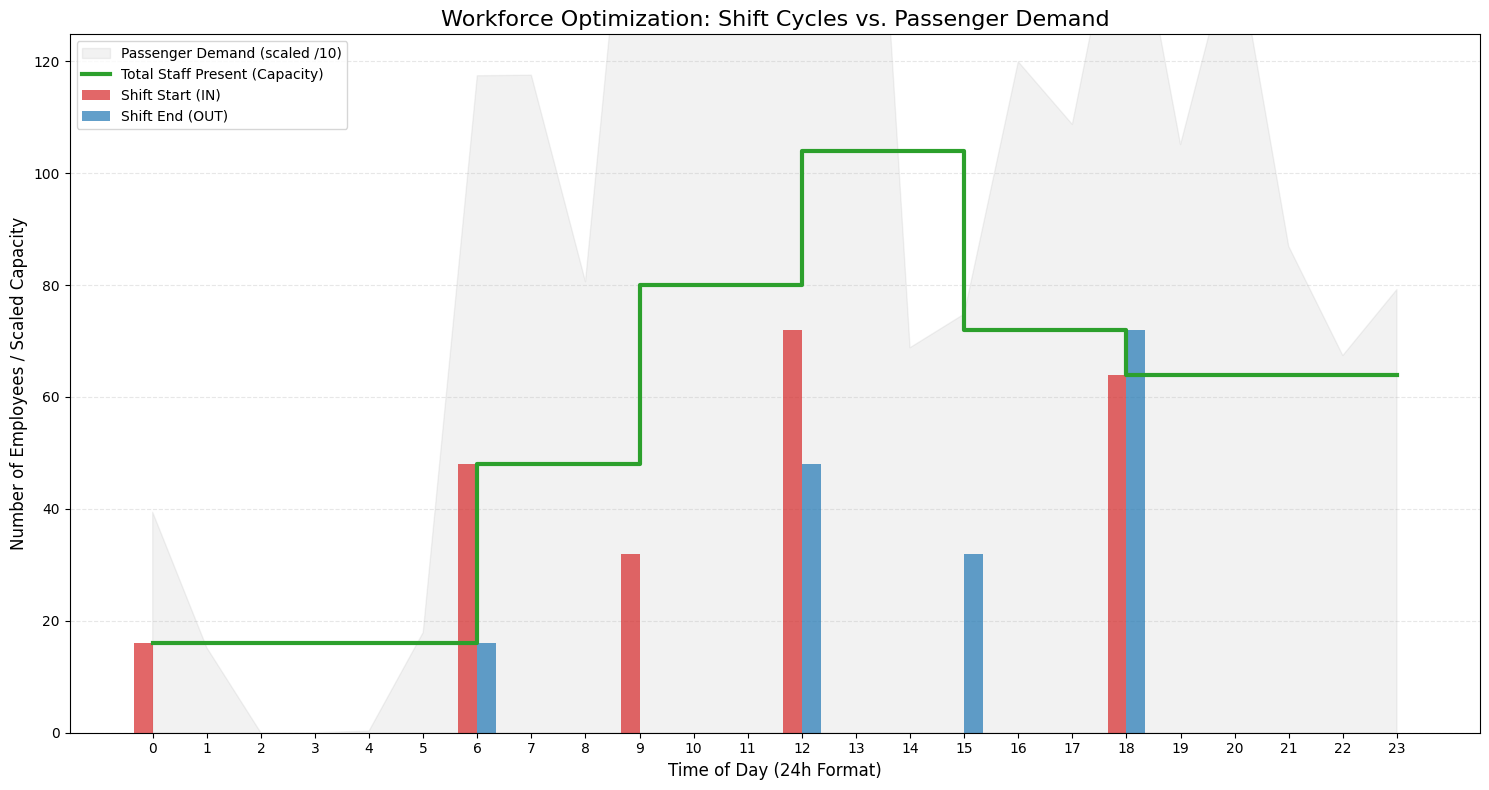

In [76]:
def plot_planning(planning):
    """
    Visualizes the relationship between passenger flow and staff scheduling.
    Shows total active staff, new shift starts (IN), and shift ends (OUT).
    """
    plt.figure(figsize=(15, 8))

    # 1. Calculate shift ends (Staff finishing their 6-hour shift)
    # We shift the 'Staff_Starting' column by 6 hours to find when they leave
    planning['Staff_Ending'] = planning['Staff_Starting'].shift(6).fillna(0)

    # 2. Background: Passenger flow (scaled for visibility)
    # We divide by 10 to keep the passenger curve and staff levels on the same axis scale
    plt.fill_between(planning['Heure'], planning['PredNbPaxTotal']/10, 
                     alpha=0.1, color='gray', label='Passenger Demand (scaled /10)')

    # 3. Total Staff Active (Step plot)
    # Represents the real-time capacity of the airport to process passengers
    plt.step(planning['Heure'], planning['Total_Staff_Present'], where='post', 
            color='#2ca02c', linewidth=3, label='Total Staff Present (Capacity)', zorder=3)

  
    width = 0.35 
 
    plt.bar(planning['Heure'] - width/2, planning['Staff_Starting'], width, 
            color='#d62728', alpha=0.7, label='Shift Start (IN)', zorder=2)

    plt.bar(planning['Heure'] + width/2, planning['Staff_Ending'], width, 
            color='#1f77b4', alpha=0.7, label='Shift End (OUT)', zorder=2)

    # Chart Styling and Labels
    plt.title("Workforce Optimization: Shift Cycles vs. Passenger Demand", fontsize=16)
    plt.xlabel("Time of Day (24h Format)", fontsize=12)
    plt.ylabel("Number of Employees / Scaled Capacity", fontsize=12)
    plt.xticks(range(24))
    
    # Adjust Y-axis limit to ensure everything is visible
    plt.ylim(0, max(planning['Total_Staff_Present'].max(), planning['Staff_Starting'].max()) * 1.2)
    
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.legend(loc='upper left')
    
    plt.tight_layout()
    plt.show()

plot_planning(planning)

In [77]:
total_employees_day = planning['Staff_Starting'].sum()
total_hours_paid = planning['Total_Staff_Present'].sum()
max_staff_simultaneous = planning['Total_Staff_Present'].max()

print(f"--- OPTIMIZATION REPORT ---")
print(f"Total number of employees to be mobilized for the day : {total_employees_day/8:.0f} teams of 8")
print(f"Total paid working hours : {total_hours_paid:.0f} h")
print(f"Peak number of staff : {max_staff_simultaneous:.0f}")
print(f"Maximum processing capacity : {planning['Lanes_Open'].max() * 200} pax/h")

--- OPTIMIZATION REPORT ---
Total number of employees to be mobilized for the day : 29 teams of 8
Total paid working hours : 1392 h
Peak number of staff : 104
Maximum processing capacity : 2600 pax/h


### Generating planning :

In [78]:
def generate_airport_report(planning, filename, hourly_rate):
    """
    Generates a detailed staff deployment report and exports it to a file.
    planning: DataFrame containing 'Staff_Starting', 'Lanes_Open', and 'Total_Staff_Present'.
    hourly_rate: Average hourly cost per employee.
    """
    lines = []
    
    # Professional Header
    header = f"{'TIME SLOT':<12} | {'LANES':<6} | {'STAFF':<7} | {'HR MOVEMENTS (IN/OUT)':<35} | {'COST'}"
    separator = "-" * 90
    
    lines.append("="*90)
    lines.append(f"OPERATIONAL REPORT - WORKFORCE RESOURCE PLANNING")
    lines.append("="*90)
    lines.append(header)
    lines.append(separator)
    
    total_cost = 0
    
    for h in range(24):
        # Data Retrieval
        arrivals = int(planning.loc[h, 'Staff_Starting'])
        departures = int(planning.loc[h-6, 'Staff_Starting']) if h >= 6 else 0
        lanes = int(planning.loc[h, 'Lanes_Open'])
        total_staff = int(planning.loc[h, 'Total_Staff_Present'])
        
        # Hourly Cost Calculation
        hour_cost = total_staff * hourly_rate
        total_cost += hour_cost
        
        # Building Movement String
        mvt_parts = []
        if arrivals > 0:
            mvt_parts.append(f"+ {arrivals:02d} SHIFT START")
        if departures > 0:
            mvt_parts.append(f"- {departures:02d} SHIFT END")
        
        mvt_str = " | ".join(mvt_parts) if mvt_parts else "---"
        
        # Row Formatting
        time_range = f"{h:02d}:00-{(h+1):02d}:00"
        row = f"{time_range:<12} | {lanes:<6} | {total_staff:<7} | {mvt_str:<35} | {hour_cost:>8,.2f} $"
        lines.append(row)

    # Footer with Totals
    lines.append(separator)
    lines.append(f"{'DAILY TOTAL':<12} | {'---':<6} | {'---':<7} | {'---':<35} | {total_cost:>8,.2f} $")
    lines.append("="*90)
    
    # 1. Console Output
    final_report = "\n".join(lines)
    print(final_report)
    
    # 2. File Export
    with open(filename, "w", encoding="utf-8") as f:
            f.write(final_report)
    print(f"\nReport successfully saved to: {filename}")
  

generate_airport_report(planning, FILENAME_REPORT, HOURLY_RATE)

OPERATIONAL REPORT - WORKFORCE RESOURCE PLANNING
TIME SLOT    | LANES  | STAFF   | HR MOVEMENTS (IN/OUT)               | COST
------------------------------------------------------------------------------------------
00:00-01:00  | 2      | 16      | + 16 SHIFT START                    |   400.00 $
01:00-02:00  | 2      | 16      | ---                                 |   400.00 $
02:00-03:00  | 2      | 16      | ---                                 |   400.00 $
03:00-04:00  | 2      | 16      | ---                                 |   400.00 $
04:00-05:00  | 2      | 16      | ---                                 |   400.00 $
05:00-06:00  | 2      | 16      | ---                                 |   400.00 $
06:00-07:00  | 6      | 48      | + 48 SHIFT START | - 16 SHIFT END   | 1,200.00 $
07:00-08:00  | 6      | 48      | ---                                 | 1,200.00 $
08:00-09:00  | 6      | 48      | ---                                 | 1,200.00 $
09:00-10:00  | 10     | 80      | + 